# Unsupervised KMeans clustering on MAE features

Trains the package's `OnlineKMeans` on features from `classifier_features.npz`.

**Flow**
1. Load features → avg-pool if 3-D → StandardScaler → PCA(64)
2. Elbow + silhouette to recommend *k*
3. Train `OnlineKMeans` (mini-batch, multiple epochs)
4. Evaluate cluster assignments against ground-truth labels
5. Visualize in 2-D PCA space
6. Save model artifacts
7. Inference cell — run on any new feature matrix

Note: Run the train_classification.ipynb notebook to generate the features.

Device: cuda
X: (7467, 120)   cells: 4371   non-cells: 3096
PCA 64 components explain 99.4% of variance


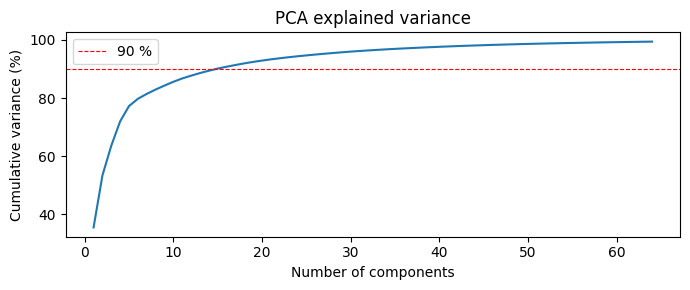

In [ ]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans as SKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

from mesoscale_cell_classification_head.clustering import OnlineKMeans

warnings.filterwarnings('ignore', category=UserWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load features
data = np.load('classifier_features.npz')
X = data['X'].astype(np.float32)
y = data['y'].astype(np.int64)
dataset_ids = data['dataset_ids']

# Reduce (N, K, K, K, C) → (N, C) if 3-D cube features were saved
if X.ndim == 5:
    X = X.mean(axis=(1, 2, 3))

print(f'X: {X.shape}   cells: {(y == 1).sum()}   non-cells: {(y == 0).sum()}')

# Normalise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (64 components, matching pipeline default)
N_PCA = 64
pca = PCA(n_components=N_PCA, random_state=42)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

cumvar = pca.explained_variance_ratio_.cumsum()
print(f'PCA {N_PCA} components explain {cumvar[-1]:.1%} of variance')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(1, N_PCA + 1), cumvar * 100)
ax.axhline(90, color='red', linestyle='--', linewidth=0.8, label='90 %')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance (%)')
ax.set_title('PCA explained variance')
ax.legend()
plt.tight_layout()
plt.show()

## Recommend *k* — elbow + silhouette

We run fast sklearn KMeans on a subsample to estimate good values of *k*.
The default is **k=2** (cells vs non-cells) but the analysis may suggest more
morphological sub-types.

Running sklearn KMeans on 5000 samples for k = 2..10
  k= 2  inertia=412,460  silhouette=0.3496
  k= 3  inertia=343,352  silhouette=0.2450
  k= 4  inertia=294,424  silhouette=0.2691
  k= 5  inertia=253,964  silhouette=0.2728
  k= 6  inertia=224,768  silhouette=0.2859
  k= 7  inertia=213,354  silhouette=0.2395
  k= 8  inertia=203,285  silhouette=0.2132
  k= 9  inertia=195,440  silhouette=0.2115
  k=10  inertia=186,457  silhouette=0.2130

Recommended k (max silhouette) : 2
Recommended k (elbow)           : 3
→ Using N_CLUSTERS = 2  (binary cell / non-cell)


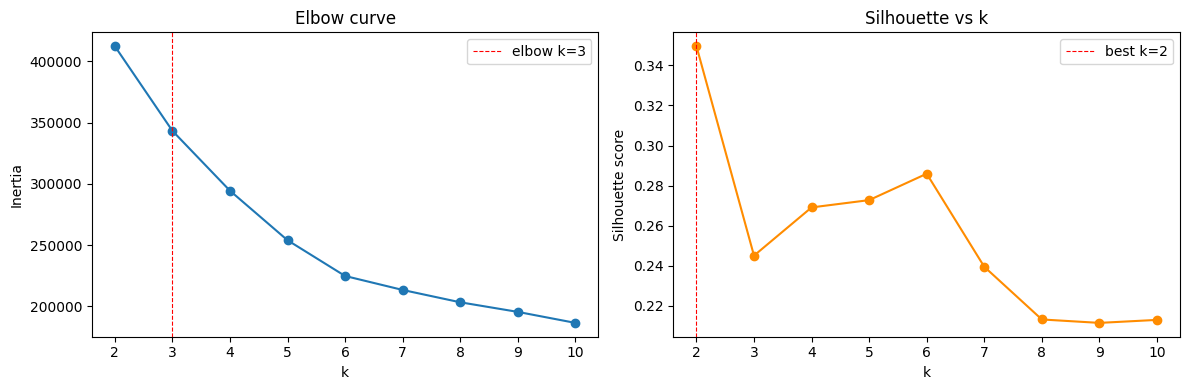

In [ ]:
MAX_K = 10
SAMPLE_SIZE = min(5000, len(X_pca))

rng = np.random.default_rng(42)
idx = rng.choice(len(X_pca), SAMPLE_SIZE, replace=False)
X_sample = X_pca[idx]

inertias, silhouettes = [], []
k_range = list(range(2, MAX_K + 1))

print(f'Running sklearn KMeans on {SAMPLE_SIZE} samples for k = 2..{MAX_K}')
for k in k_range:
    km_sk = SKMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    labels_sk = km_sk.fit_predict(X_sample)
    inertias.append(km_sk.inertia_)
    sil = silhouette_score(X_sample, labels_sk,
                           sample_size=min(2000, SAMPLE_SIZE), random_state=42)
    silhouettes.append(sil)
    print(f'  k={k:2d}  inertia={km_sk.inertia_:,.0f}  silhouette={sil:.4f}')

best_k_sil = k_range[int(np.argmax(silhouettes))]

# Elbow via second-derivative kneepoint
deltas = np.diff(inertias)
best_k_elbow = k_range[int(np.argmin(deltas)) + 1]

print(f'\nRecommended k (max silhouette) : {best_k_sil}')
print(f'Recommended k (elbow)           : {best_k_elbow}')
print('Using N_CLUSTERS = 2  (binary cell / non-cell)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, 'o-')
ax1.axvline(best_k_elbow, color='red', linestyle='--', linewidth=0.8,
            label=f'elbow k={best_k_elbow}')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow curve'); ax1.legend()

ax2.plot(k_range, silhouettes, 'o-', color='darkorange')
ax2.axvline(best_k_sil, color='red', linestyle='--', linewidth=0.8,
            label=f'best k={best_k_sil}')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette vs k'); ax2.legend()

plt.tight_layout()
plt.show()

## Train `OnlineKMeans`

Mini-batch EMA updates with cosine similarity.  Multiple epochs shuffle the data
each time so all samples influence the centroids.

Epoch  1/15  mean_cos_dist=0.8070  c0=4150  c1=3317
Epoch  2/15  mean_cos_dist=0.5790  c0=8550  c1=6384
Epoch  3/15  mean_cos_dist=0.4956  c0=12976  c1=9425
Epoch  4/15  mean_cos_dist=0.4738  c0=17477  c1=12391
Epoch  5/15  mean_cos_dist=0.4678  c0=22053  c1=15282
Epoch  6/15  mean_cos_dist=0.4668  c0=26709  c1=18093
Epoch  7/15  mean_cos_dist=0.4650  c0=31473  c1=20796
Epoch  8/15  mean_cos_dist=0.4655  c0=36298  c1=23438
Epoch  9/15  mean_cos_dist=0.4635  c0=41203  c1=26000
Epoch 10/15  mean_cos_dist=0.4627  c0=46170  c1=28500
Epoch 11/15  mean_cos_dist=0.4619  c0=51190  c1=30947
Epoch 12/15  mean_cos_dist=0.4609  c0=56252  c1=33352
Epoch 13/15  mean_cos_dist=0.4621  c0=61331  c1=35740
Epoch 14/15  mean_cos_dist=0.4616  c0=66413  c1=38125
Epoch 15/15  mean_cos_dist=0.4605  c0=71500  c1=40505


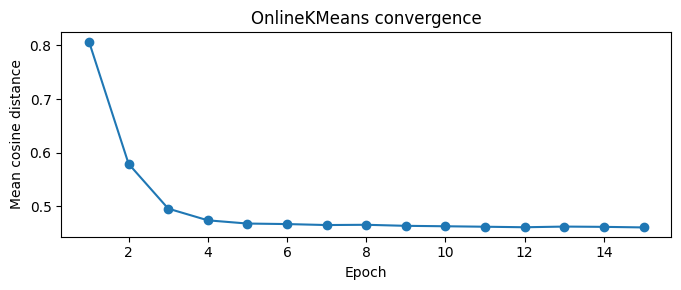

In [9]:
N_CLUSTERS = 2   # set to best_k_sil to use the recommended value
N_EPOCHS   = 15
BATCH_SIZE = 256
LR         = 0.05

kmeans = OnlineKMeans(
    n_clusters=N_CLUSTERS,
    dim=N_PCA,
    lr=LR,
    device=str(device),
)

X_t = torch.from_numpy(X_pca).to(device)
N = len(X_t)

dist_history = []

for epoch in range(N_EPOCHS):
    perm = torch.randperm(N, device=device)
    epoch_dists = []
    for i in range(0, N, BATCH_SIZE):
        batch = X_t[perm[i : i + BATCH_SIZE]]
        _, dists = kmeans.update(batch)
        epoch_dists.append(dists.mean().item())
    mean_d = float(np.mean(epoch_dists))
    dist_history.append(mean_d)
    counts_str = '  '.join(f'c{i}={int(kmeans.counts[i].item())}'
                            for i in range(N_CLUSTERS))
    print(f'Epoch {epoch+1:2d}/{N_EPOCHS}  mean_cos_dist={mean_d:.4f}  {counts_str}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, N_EPOCHS + 1), dist_history, 'o-')
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean cosine distance')
ax.set_title('OnlineKMeans convergence')
plt.tight_layout()
plt.show()

## Evaluate against ground-truth labels

Cluster IDs are arbitrary, so we use the Hungarian algorithm to find the
permutation that best aligns clusters to ground-truth classes before
reporting metrics.

Adjusted Rand Index : 0.3531  (1=perfect, 0=random)
Cluster → class map : {1: 0, 0: 1}

              precision    recall  f1-score   support

    non-cell     0.8334    0.6415    0.7249      3096
        cell     0.7817    0.9092    0.8406      4371

    accuracy                         0.7982      7467
   macro avg     0.8075    0.7753    0.7828      7467
weighted avg     0.8031    0.7982    0.7927      7467



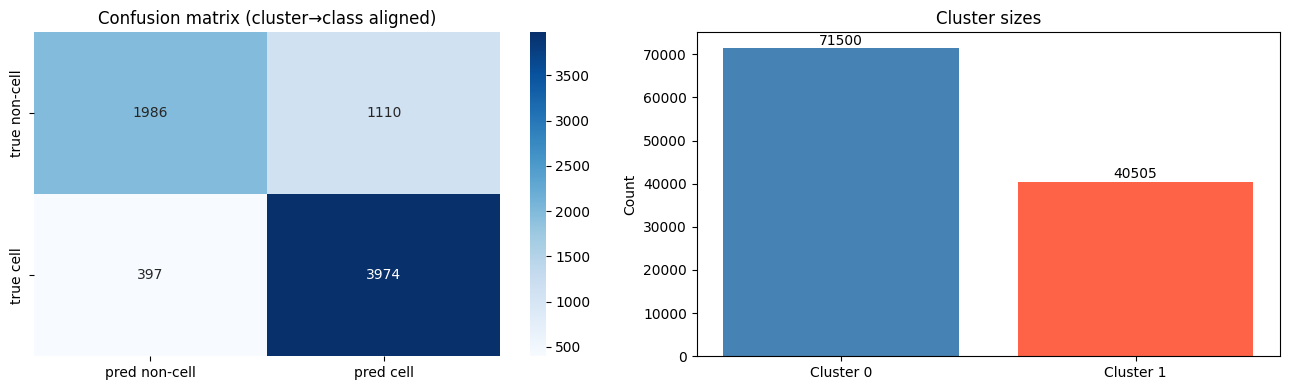

In [10]:
with torch.no_grad():
    cluster_labels = kmeans.predict(X_t).cpu().numpy()

# Hungarian alignment: cluster id → class id
cm_raw = confusion_matrix(y, cluster_labels)
row_ind, col_ind = linear_sum_assignment(-cm_raw)
label_map = {int(c): int(r) for r, c in zip(row_ind, col_ind)}
mapped = np.array([label_map[int(l)] for l in cluster_labels])

ari = adjusted_rand_score(y, cluster_labels)
print(f'Adjusted Rand Index : {ari:.4f}  (1=perfect, 0=random)')
print(f'Cluster → class map : {label_map}')
print()
print(classification_report(y, mapped, target_names=['non-cell', 'cell'], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm_mapped = confusion_matrix(y, mapped)
sns.heatmap(cm_mapped, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['pred non-cell', 'pred cell'],
            yticklabels=['true non-cell', 'true cell'])
axes[0].set_title('Confusion matrix (cluster→class aligned)')

# Cluster sizes
ck = [int(kmeans.counts[i].item()) for i in range(N_CLUSTERS)]
axes[1].bar([f'Cluster {i}' for i in range(N_CLUSTERS)],
            ck, color=['steelblue', 'tomato'][:N_CLUSTERS])
for i, v in enumerate(ck):
    axes[1].text(i, v + max(ck) * 0.01, str(v), ha='center')
axes[1].set_title('Cluster sizes'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Visualise in 2-D PCA space

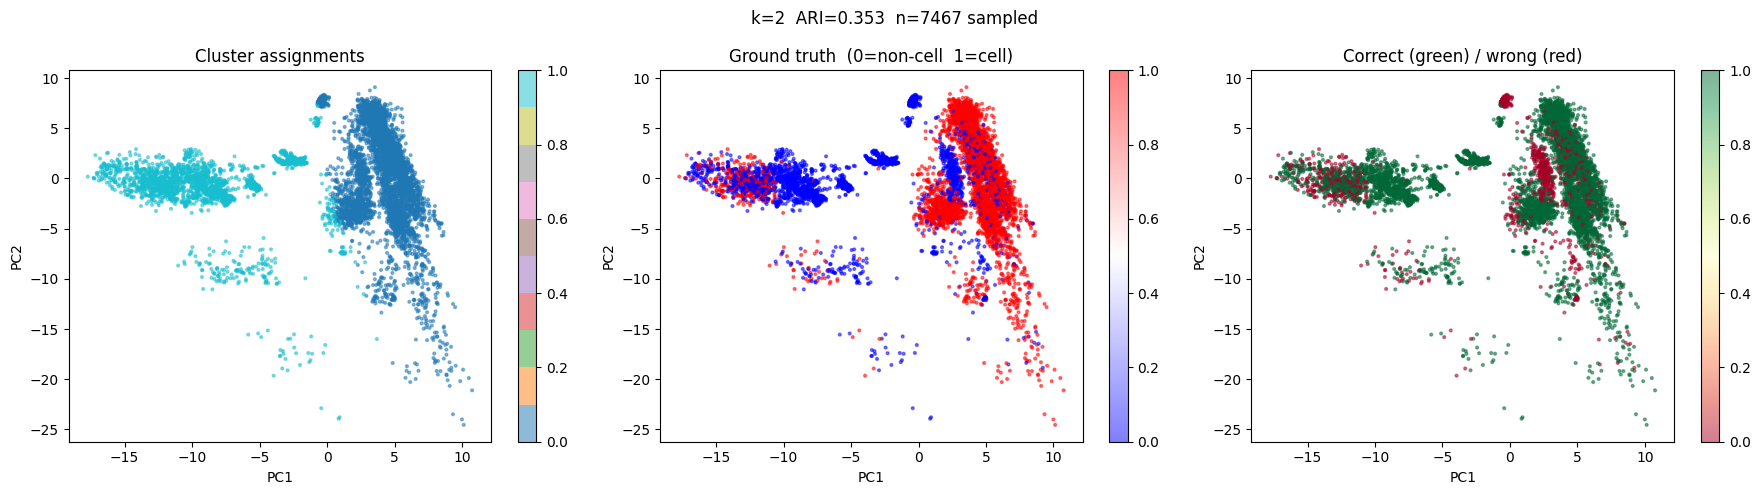


Cluster purity breakdown:
  Cluster 0:  5084 pts   cells=3974 (78.2%)   non-cells=1110 (21.8%)
  Cluster 1:  2383 pts   cells=397 (16.7%)   non-cells=1986 (83.3%)


In [11]:
# Separate 2-component PCA for visualisation only
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

# Subsample for readable scatter plots
VIZ_N = min(8000, len(X_2d))
viz_idx = rng.choice(len(X_2d), VIZ_N, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cluster assignments
sc0 = axes[0].scatter(
    X_2d[viz_idx, 0], X_2d[viz_idx, 1],
    c=cluster_labels[viz_idx], cmap='tab10',
    s=4, alpha=0.5, rasterized=True,
)
plt.colorbar(sc0, ax=axes[0])
axes[0].set_title('Cluster assignments'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Ground-truth labels
sc1 = axes[1].scatter(
    X_2d[viz_idx, 0], X_2d[viz_idx, 1],
    c=y[viz_idx], cmap='bwr',
    s=4, alpha=0.5, rasterized=True,
)
plt.colorbar(sc1, ax=axes[1])
axes[1].set_title('Ground truth  (0=non-cell  1=cell)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# Error map: correct vs wrong
correct = (mapped[viz_idx] == y[viz_idx]).astype(int)
sc2 = axes[2].scatter(
    X_2d[viz_idx, 0], X_2d[viz_idx, 1],
    c=correct, cmap='RdYlGn',
    s=4, alpha=0.5, rasterized=True,
)
plt.colorbar(sc2, ax=axes[2])
axes[2].set_title('Correct (green) / wrong (red)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.suptitle(f'k={N_CLUSTERS}  ARI={ari:.3f}  n={VIZ_N} sampled', fontsize=12)
plt.tight_layout()
plt.show()

# Per-cluster ground-truth breakdown
print('\nCluster purity breakdown:')
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    n_c   = (y[mask] == 1).sum()
    n_nc  = (y[mask] == 0).sum()
    total = mask.sum()
    print(f'  Cluster {c}: {total:5d} pts   '
          f'cells={n_c} ({n_c/total:.1%})   '
          f'non-cells={n_nc} ({n_nc/total:.1%})')

## Interpretraton

The clusters are embeded into each other, clustering algorithms would not be able to properly separate them. This means some more work should be done in the data inputs (e.g., extra channel such as the background channel) or in the self-supervised approach.

## Gaussian Mixture Model (full covariance)

GMM replaces the spherical Voronoi partition of K-means with a probabilistic
model where each component is a **full-covariance Gaussian** — an ellipsoid of
arbitrary orientation and eccentricity.  Two practical advantages over K-means:

* **Non-spherical clusters** — each component independently learns the shape and
  orientation of its distribution, so elongated or correlated feature clouds are
  modelled correctly.
* **Soft probabilities** — `predict_proba` gives *P(cell | features)* for each
  point.  This acts as a calibrated score that can be threshold-tuned just like
  the MLP classifier output.

Model selection uses **BIC** (Bayesian Information Criterion, penalises model
complexity more heavily than AIC) to recommend the best *k*.


Fitting GMM for k = 2..10 (n_init=3, full covariance)
  k= 2  BIC=505,657  AIC=475,985
  k= 3  BIC=431,033  AIC=386,521
  k= 4  BIC=367,889  AIC=308,537
  k= 5  BIC=347,323  AIC=273,132
  k= 6  BIC=314,352  AIC=225,321
  k= 7  BIC=322,576  AIC=218,705
  k= 8  BIC=316,443  AIC=197,733
  k= 9  BIC=323,401  AIC=189,851
  k=10  BIC=300,302  AIC=151,912

Recommended k — BIC: 10   AIC: 10
→ Using N_CLUSTERS_GMM = 2  (binary cell / non-cell)


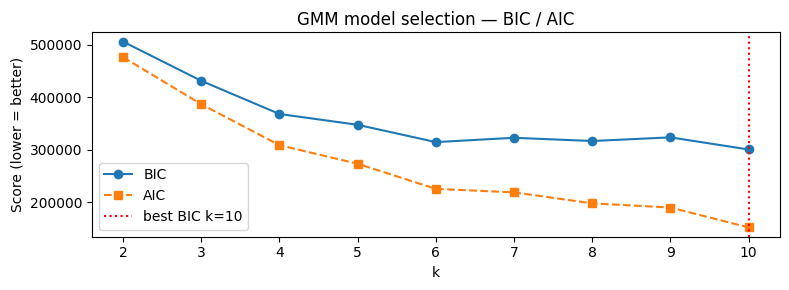


GMM converged: True   log-likelihood: -31.2982


In [ ]:
from sklearn.mixture import GaussianMixture

MAX_K_GMM = 10
k_range_gmm = list(range(2, MAX_K_GMM + 1))
bics, aics = [], []

print(f'Fitting GMM for k = 2..{MAX_K_GMM} (n_init=3, full covariance)')
for k in k_range_gmm:
    gm_tmp = GaussianMixture(n_components=k, covariance_type='full',
                             random_state=42, max_iter=200, n_init=3)
    gm_tmp.fit(X_pca)
    bics.append(gm_tmp.bic(X_pca))
    aics.append(gm_tmp.aic(X_pca))
    print(f'  k={k:2d}  BIC={bics[-1]:,.0f}  AIC={aics[-1]:,.0f}')

best_k_bic = k_range_gmm[int(np.argmin(bics))]
best_k_aic = k_range_gmm[int(np.argmin(aics))]
print(f'\nRecommended k — BIC: {best_k_bic}   AIC: {best_k_aic}')
print('→ Using N_CLUSTERS_GMM = 2  (binary cell / non-cell)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(k_range_gmm, bics, 'o-', label='BIC')
ax.plot(k_range_gmm, aics, 's--', label='AIC')
ax.axvline(best_k_bic, color='red', linestyle=':',
           label=f'best BIC k={best_k_bic}')
ax.set_xlabel('k'); ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM model selection — BIC / AIC')
ax.legend()
plt.tight_layout()
plt.show()

# Fit final GMM
N_CLUSTERS_GMM = 2   # change to best_k_bic to use the recommended value
gmm = GaussianMixture(
    n_components=N_CLUSTERS_GMM,
    covariance_type='full',
    random_state=42,
    max_iter=300,
    n_init=5,
)
gmm.fit(X_pca)
print(f'\nGMM converged: {gmm.converged_}   '
      f'log-likelihood: {gmm.lower_bound_:.4f}')


GMM — Adjusted Rand Index : 0.3485
GMM — Cluster → class map : {0: 0, 1: 1}

              precision    recall  f1-score   support

    non-cell     0.8484    0.6198    0.7163      3096
        cell     0.7739    0.9215    0.8413      4371

    accuracy                         0.7964      7467
   macro avg     0.8111    0.7707    0.7788      7467
weighted avg     0.8048    0.7964    0.7895      7467



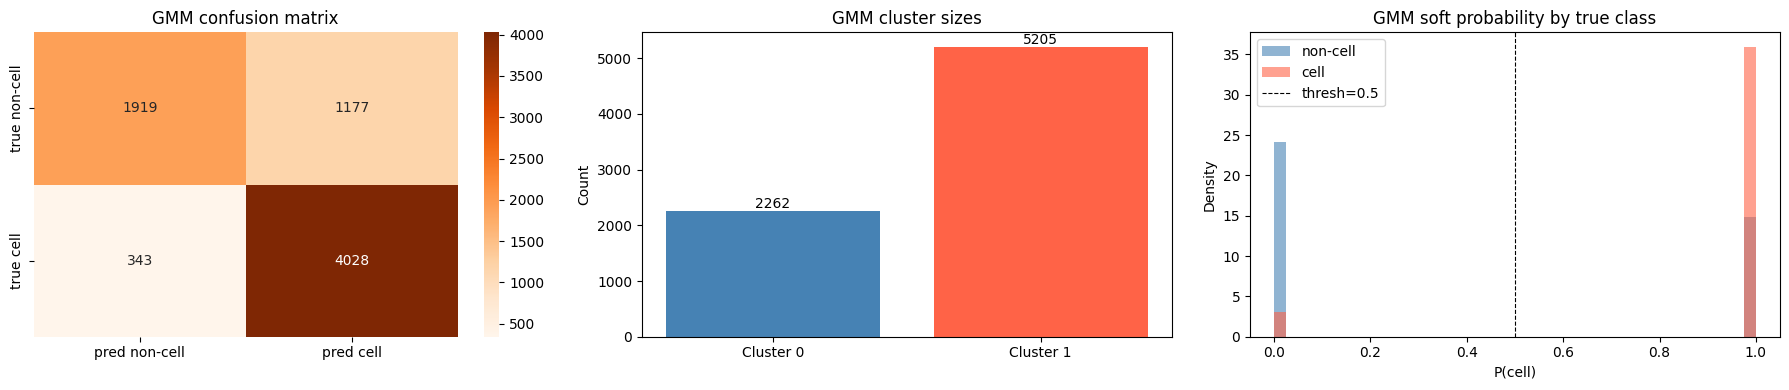


GMM cluster purity:
  Cluster 0:  2262 pts  cells=343 (15.2%)  non-cells=1919 (84.8%)
  Cluster 1:  5205 pts  cells=4028 (77.4%)  non-cells=1177 (22.6%)


In [ ]:
gmm_cluster_labels = gmm.predict(X_pca)
gmm_cell_proba     = gmm.predict_proba(X_pca)[:, 1]  # component 1 — may need to flip below

# Hungarian alignment
cm_gmm_raw = confusion_matrix(y, gmm_cluster_labels)
row_gmm, col_gmm = linear_sum_assignment(-cm_gmm_raw)
gmm_label_map = {int(c): int(r) for r, c in zip(row_gmm, col_gmm)}
gmm_mapped = np.array([gmm_label_map[int(l)] for l in gmm_cluster_labels])

# Align P(cell) to the correct component
cell_component = int({v: k for k, v in gmm_label_map.items()}[1])
gmm_cell_proba = gmm.predict_proba(X_pca)[:, cell_component]

gmm_ari = adjusted_rand_score(y, gmm_cluster_labels)
print(f'GMM — Adjusted Rand Index : {gmm_ari:.4f}')
print(f'GMM — Cluster -> class map : {gmm_label_map}')
print()
print(classification_report(y, gmm_mapped, target_names=['non-cell', 'cell'], digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Confusion matrix
sns.heatmap(confusion_matrix(y, gmm_mapped), annot=True, fmt='d', cmap='Oranges',
            ax=axes[0],
            xticklabels=['pred non-cell', 'pred cell'],
            yticklabels=['true non-cell', 'true cell'])
axes[0].set_title('GMM confusion matrix')

# Cluster size bar
gmm_sizes = [(gmm_cluster_labels == c).sum() for c in range(N_CLUSTERS_GMM)]
axes[1].bar([f'Cluster {i}' for i in range(N_CLUSTERS_GMM)],
            gmm_sizes, color=['steelblue', 'tomato'][:N_CLUSTERS_GMM])
for i, v in enumerate(gmm_sizes):
    axes[1].text(i, v + max(gmm_sizes) * 0.01, str(v), ha='center')
axes[1].set_title('GMM cluster sizes'); axes[1].set_ylabel('Count')

# P(cell) probability histogram per true class
bins = np.linspace(0, 1, 40)
for label, name, color in [(0, 'non-cell', 'steelblue'), (1, 'cell', 'tomato')]:
    axes[2].hist(gmm_cell_proba[y == label], bins=bins, alpha=0.6,
                 label=name, color=color, density=True)
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='thresh=0.5')
axes[2].set_xlabel('P(cell)'); axes[2].set_ylabel('Density')
axes[2].set_title('GMM soft probability by true class')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\nGMM cluster purity:')
for c in range(N_CLUSTERS_GMM):
    mask = gmm_cluster_labels == c
    n_c, n_nc, total = (y[mask] == 1).sum(), (y[mask] == 0).sum(), mask.sum()
    print(f'  Cluster {c}: {total:5d} pts  cells={n_c} ({n_c/total:.1%})  non-cells={n_nc} ({n_nc/total:.1%})')


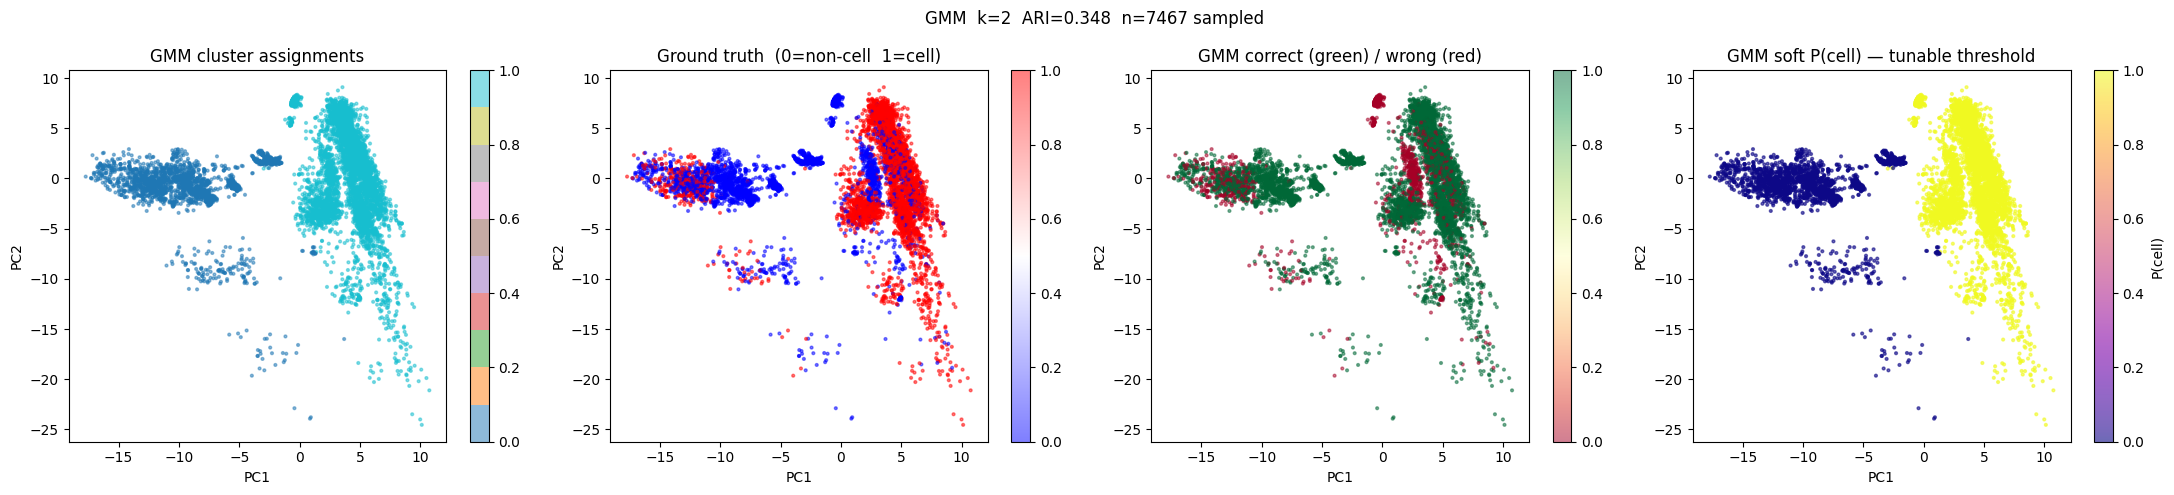

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Panel 1 — GMM cluster assignments
sc0 = axes[0].scatter(
    X_2d[viz_idx, 0], X_2d[viz_idx, 1],
    c=gmm_cluster_labels[viz_idx], cmap='tab10',
    s=4, alpha=0.5, rasterized=True,
)
plt.colorbar(sc0, ax=axes[0])
axes[0].set_title('GMM cluster assignments')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Panel 2 — Ground truth
sc1 = axes[1].scatter(
    X_2d[viz_idx, 0], X_2d[viz_idx, 1],
    c=y[viz_idx], cmap='bwr',
    s=4, alpha=0.5, rasterized=True,
)
plt.colorbar(sc1, ax=axes[1])
axes[1].set_title('Ground truth  (0=non-cell  1=cell)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# Panel 3 — Error map
gmm_correct = (gmm_mapped[viz_idx] == y[viz_idx]).astype(int)
sc2 = axes[2].scatter(
    X_2d[viz_idx, 0], X_2d[viz_idx, 1],
    c=gmm_correct, cmap='RdYlGn',
    s=4, alpha=0.5, rasterized=True,
)
plt.colorbar(sc2, ax=axes[2])
axes[2].set_title('GMM correct (green) / wrong (red)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

# Panel 4 — Soft P(cell) probability
sc3 = axes[3].scatter(
    X_2d[viz_idx, 0], X_2d[viz_idx, 1],
    c=gmm_cell_proba[viz_idx], cmap='plasma',
    vmin=0, vmax=1,
    s=4, alpha=0.6, rasterized=True,
)
plt.colorbar(sc3, ax=axes[3], label='P(cell)')
axes[3].set_title('GMM soft P(cell) — tunable threshold')
axes[3].set_xlabel('PC1'); axes[3].set_ylabel('PC2')

plt.suptitle(f'GMM  k={N_CLUSTERS_GMM}  ARI={gmm_ari:.3f}  n={VIZ_N} sampled', fontsize=12)
plt.tight_layout()
plt.show()


Metric             KMeans        GMM   Δ (GMM−KM)
------------------------------------------------
Precision          0.7817     0.7739      -0.0078
Recall             0.9092     0.9215      +0.0124
F1                 0.8406     0.8413      +0.0007
Bal. Acc           0.7753     0.7707      -0.0046
ARI                0.3531     0.3485      -0.0046


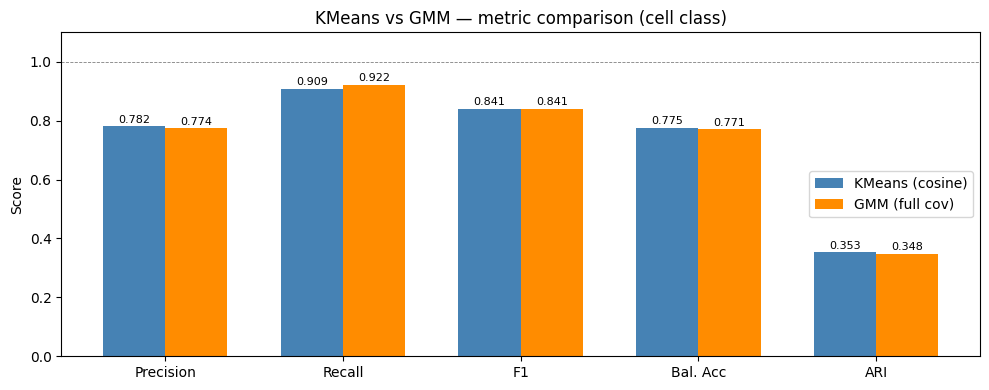

In [15]:
from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support

def _metrics(y_true, y_pred, y_prob=None):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1)
    ba = balanced_accuracy_score(y_true, y_pred)
    ari_val = adjusted_rand_score(y_true, y_pred)
    return {'Precision': p, 'Recall': r, 'F1': f, 'Bal. Acc': ba, 'ARI': ari_val}

km_metrics  = _metrics(y, mapped)
gmm_metrics = _metrics(y, gmm_mapped)

metric_names = list(km_metrics.keys())
km_vals  = [km_metrics[m]  for m in metric_names]
gmm_vals = [gmm_metrics[m] for m in metric_names]

print(f'{"Metric":<14} {"KMeans":>10} {"GMM":>10} {"Δ (GMM−KM)":>12}')
print('-' * 48)
for m, kv, gv in zip(metric_names, km_vals, gmm_vals):
    print(f'{m:<14} {kv:>10.4f} {gv:>10.4f} {gv - kv:>+12.4f}')

x = np.arange(len(metric_names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
bars_km  = ax.bar(x - w/2, km_vals,  w, label='KMeans (cosine)',  color='steelblue')
bars_gmm = ax.bar(x + w/2, gmm_vals, w, label='GMM (full cov)',   color='darkorange')

for bar in (*bars_km, *bars_gmm):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score'); ax.set_title('KMeans vs GMM — metric comparison (cell class)')
ax.legend(); ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.6)
plt.tight_layout()
plt.show()


## Save all model artifacts

In [ ]:
# KMeans
torch.save(kmeans.state_dict(), 'kmeans_state.pt')
np.save('kmeans_label_map.npy', label_map)

# GMM
joblib.dump(gmm, 'gmm_model.pkl')
np.save('gmm_label_map.npy', gmm_label_map)

# Shared
joblib.dump(scaler, 'kmeans_scaler.pkl')
joblib.dump(pca,    'kmeans_pca.pkl')

print('Saved:')
print('  kmeans_state.pt      — OnlineKMeans centroids + counts')
print('  kmeans_label_map.npy — KMeans cluster → class mapping')
print('  gmm_model.pkl        — GaussianMixture (full covariance)')
print('  gmm_label_map.npy    — GMM cluster → class mapping')
print('  kmeans_scaler.pkl    — StandardScaler (shared)')
print('  kmeans_pca.pkl       — PCA 64-component transform (shared)')


Saved:
  kmeans_state.pt      — OnlineKMeans centroids + counts
  kmeans_label_map.npy — KMeans cluster → class mapping
  gmm_model.pkl        — GaussianMixture (full covariance)
  gmm_label_map.npy    — GMM cluster → class mapping
  kmeans_scaler.pkl    — StandardScaler (shared)
  kmeans_pca.pkl       — PCA 64-component transform (shared)


In [ ]:
def predict_gmm(
    feature_matrix: np.ndarray,
    scaler_path:    str = 'kmeans_scaler.pkl',
    pca_path:       str = 'kmeans_pca.pkl',
    gmm_path:       str = 'gmm_model.pkl',
    label_map_path: str = 'gmm_label_map.npy',
) -> tuple[np.ndarray, np.ndarray]:
    """Return (hard_labels, cell_probability) for new feature vectors.

    hard_labels : (N,) int64  — 0=non-cell, 1=cell
    cell_proba  : (N,) float  — P(cell | features), threshold as needed
    """
    if feature_matrix.ndim == 5:
        feature_matrix = feature_matrix.mean(axis=(1, 2, 3))

    sc = joblib.load(scaler_path)
    pc = joblib.load(pca_path)
    gm = joblib.load(gmm_path)
    lm = np.load(label_map_path, allow_pickle=True).item()

    X_sc = sc.transform(feature_matrix.astype(np.float32))
    X_pc = pc.transform(X_sc)

    cluster_ids = gm.predict(X_pc)
    proba_all   = gm.predict_proba(X_pc)

    hard = np.array([lm[int(c)] for c in cluster_ids], dtype=np.int64)

    # Which GMM component maps to "cell"?
    cell_component = int({v: k for k, v in lm.items()}[1])
    cell_proba = proba_all[:, cell_component]

    return hard, cell_proba


# Sanity check on training data
gmm_preds_inf, gmm_proba_inf = predict_gmm(X)
print('GMM inference on training data (sanity check):')
print(f'  cells predicted:     {(gmm_preds_inf == 1).sum()}')
print(f'  non-cells predicted: {(gmm_preds_inf == 0).sum()}')
print()
print(classification_report(y, gmm_preds_inf, target_names=['non-cell', 'cell'], digits=4))


GMM inference on training data (sanity check):
  cells predicted:     5205
  non-cells predicted: 2262

              precision    recall  f1-score   support

    non-cell     0.8484    0.6198    0.7163      3096
        cell     0.7739    0.9215    0.8413      4371

    accuracy                         0.7964      7467
   macro avg     0.8111    0.7707    0.7788      7467
weighted avg     0.8048    0.7964    0.7895      7467



## Inference on new points

Provide any `(N, C=120)` feature matrix (or `(N, K, K, K, C)` cube features —
spatial avg-pool is applied automatically).

In [ ]:
def predict_kmeans(
    feature_matrix: np.ndarray,
    scaler_path:    str = 'kmeans_scaler.pkl',
    pca_path:       str = 'kmeans_pca.pkl',
    kmeans_path:    str = 'kmeans_state.pt',
    label_map_path: str = 'kmeans_label_map.npy',
    device:         str = 'cuda' if torch.cuda.is_available() else 'cpu',
) -> np.ndarray:
    """Return class predictions (0=non-cell, 1=cell) for new feature vectors."""
    if feature_matrix.ndim == 5:
        feature_matrix = feature_matrix.mean(axis=(1, 2, 3))

    sc  = joblib.load(scaler_path)
    pc  = joblib.load(pca_path)
    lm  = np.load(label_map_path, allow_pickle=True).item()

    X_sc  = sc.transform(feature_matrix.astype(np.float32))
    X_pc  = pc.transform(X_sc).astype(np.float32)

    state = torch.load(kmeans_path, map_location=device, weights_only=False)
    km    = OnlineKMeans(n_clusters=state['k'], dim=X_pc.shape[1], device=device)
    km.load_state_dict(state, device=device)

    with torch.no_grad():
        cluster_ids = km.predict(torch.from_numpy(X_pc).to(device)).cpu().numpy()

    return np.array([lm[int(c)] for c in cluster_ids], dtype=np.int64)


# Sanity check: run on the training data
new_preds = predict_kmeans(X)
print('Inference on training data (sanity check):')
print(f'  cells predicted:     {(new_preds == 1).sum()}')
print(f'  non-cells predicted: {(new_preds == 0).sum()}')
print()
print(classification_report(y, new_preds, target_names=['non-cell', 'cell'], digits=4))

Inference on training data (sanity check):
  cells predicted:     5084
  non-cells predicted: 2383

              precision    recall  f1-score   support

    non-cell     0.8334    0.6415    0.7249      3096
        cell     0.7817    0.9092    0.8406      4371

    accuracy                         0.7982      7467
   macro avg     0.8075    0.7753    0.7828      7467
weighted avg     0.8031    0.7982    0.7927      7467

